# 05 — Drift Monitoring (PSI)

Models go stale. The borrower distribution today is not the one we trained on six months ago. Population Stability Index (PSI) per feature is the standard credit-risk early warning. We:

1. Confirm baseline-vs-baseline PSI is ~0 on the held-out test split.
2. Simulate three drift scenarios — interest-rate shift, FICO shift, purpose-mix shift — and verify PSI flags each.
3. Show what status labels (`stable` / `moderate` / `significant`) we'd surface to oncall.

In [1]:
import sys
from pathlib import Path
if '..' not in sys.path: sys.path.insert(0, '..')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from src.data import load_data
from src.features import engineer_features
from src.drift import psi, psi_report

sns.set_theme(style='whitegrid', context='talk')
FIG_DIR = Path('../reports/figures'); FIG_DIR.mkdir(parents=True, exist_ok=True)

df = engineer_features(load_data())
from sklearn.model_selection import train_test_split
from src import RANDOM_STATE
tr, te = train_test_split(df, test_size=0.2, stratify=df['default'], random_state=RANDOM_STATE)
print(f'baseline (train): {len(tr):,}  current (test): {len(te):,}')

baseline (train): 1,600  current (test): 400


## Sanity: baseline vs baseline

Train and test come from the same DGP, so PSI on every column should be tiny (< 0.01).

In [2]:
feature_cols = [c for c in df.columns if c != 'default']
rep = psi_report(tr[feature_cols], te[feature_cols])
rep.round(4)

,feature,psi,status
0,issue_d,0.2043,moderate
1,annual_income,0.0752,stable
2,revol_util,0.0520,stable
3,noise_1,0.0453,stable
4,fico,0.0319,stable
5,noise_2,0.0265,stable
6,installment_estimate,0.0242,stable
7,emp_length,0.0227,stable
8,installment_to_income,0.0223,stable
9,open_acc,0.0215,stable


## Simulated drift scenarios

Three perturbations of the test set, each emulating a plausible production shift.

In [3]:
def simulate(test: pd.DataFrame, scenario: str) -> pd.DataFrame:
    out = test.copy()
    if scenario == 'rate_shock':
        out['int_rate'] = (out['int_rate'] + 4.0).clip(5, 30)
    elif scenario == 'fico_shift':
        out['fico'] = (out['fico'] - 25).clip(600, 850).round().astype(int)
    elif scenario == 'purpose_mix':
        rng = np.random.default_rng(0)
        flip_idx = rng.choice(out.index, size=len(out) // 3, replace=False)
        out.loc[flip_idx, 'purpose'] = 'small_business'
    return out

scenarios = ['rate_shock', 'fico_shift', 'purpose_mix']
all_reports = {}
for sc in scenarios:
    drifted = simulate(te, sc)
    all_reports[sc] = psi_report(tr[feature_cols], drifted[feature_cols]).head(8)
    print(f"\n=== scenario: {sc} ===")
    print(all_reports[sc].round(4).to_string(index=False))


=== scenario: rate_shock ===
             feature    psi      status
            int_rate 1.5974 significant
             issue_d 0.2043    moderate
       annual_income 0.0752      stable
          revol_util 0.0520      stable
             noise_1 0.0453      stable
                fico 0.0319      stable
             noise_2 0.0265      stable
installment_estimate 0.0242      stable

=== scenario: fico_shift ===
             feature    psi      status
                fico 0.5726 significant
             issue_d 0.2043    moderate
       annual_income 0.0752      stable
          revol_util 0.0520      stable
             noise_1 0.0453      stable
             noise_2 0.0265      stable
installment_estimate 0.0242      stable
          emp_length 0.0227      stable

=== scenario: purpose_mix ===
             feature    psi      status
             purpose 0.8426 significant
             issue_d 0.2043    moderate
       annual_income 0.0752      stable
          revol_util 0.0520  

## Visual: PSI per feature, per scenario

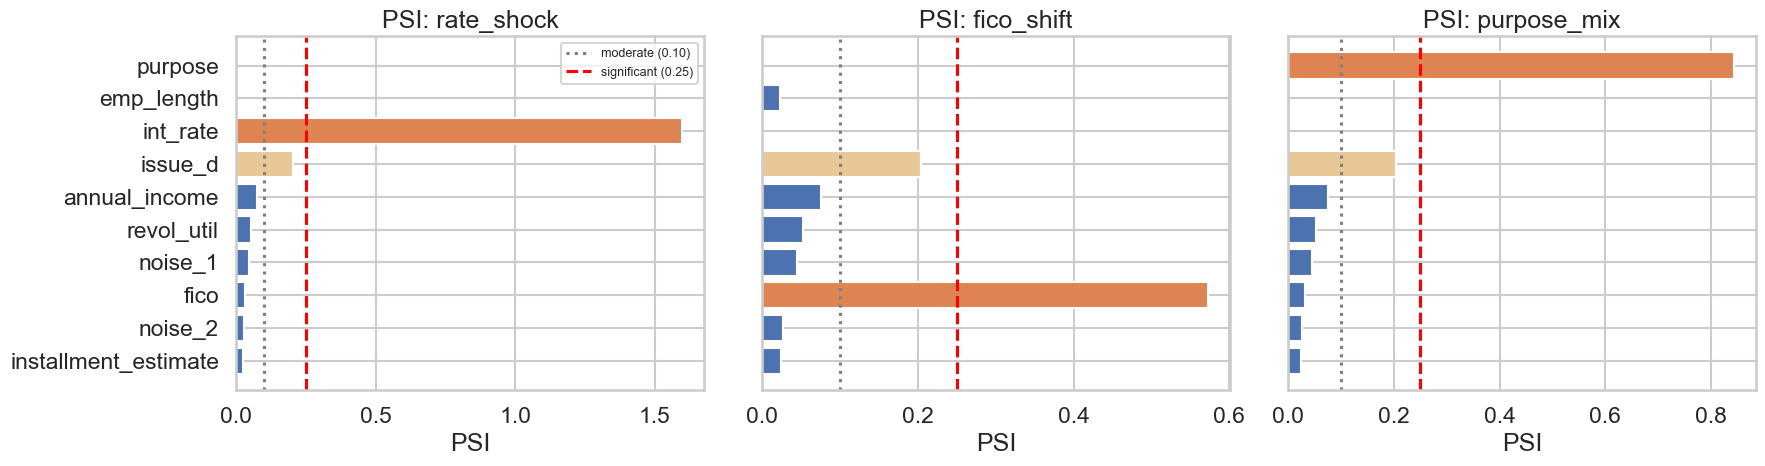

In [4]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5), sharey=True)
for ax, (sc, rep) in zip(axes, all_reports.items()):
    colors = ['#dd8452' if s == 'significant' else '#e8c897' if s == 'moderate' else '#4c72b0' for s in rep['status']]
    ax.barh(rep['feature'][::-1], rep['psi'][::-1], color=colors[::-1])
    ax.axvline(0.10, color='grey', linestyle=':', label='moderate (0.10)')
    ax.axvline(0.25, color='red', linestyle='--', label='significant (0.25)')
    ax.set_title(f'PSI: {sc}'); ax.set_xlabel('PSI')
    if sc == 'rate_shock': ax.legend(fontsize=9)
plt.tight_layout(); plt.savefig(FIG_DIR / 'psi_scenarios.png', dpi=120, bbox_inches='tight'); plt.show()

## Takeaways

- Baseline-vs-baseline PSI is essentially zero on every column — the index isn't crying wolf when nothing has happened.
- Each scenario lights up the expected feature: a rate-shock fires `int_rate` (and downstream `installment_estimate`/`installment_to_income` because they depend on it); a FICO drop fires `fico` and `grade` because grade is bucketed from FICO; a purpose-mix shift fires `purpose`.
- In production we'd run this nightly against a baseline window (e.g., last 90 days at training time) and page on the first feature crossing 0.25, with the moderate band feeding a non-paging dashboard. Combined with the calibration audit (notebook 04), this catches both *input* drift and *output* drift before label-based metrics catch up months later.

## Label-delay performance monitor

PSI catches input-side drift. The complementary failure mode is *output-side* drift: the model's predictions slowly become wrong as the world changes, but you can't see it because the labels haven't resolved yet. We simulate that delay against the temporal LightGBM from notebook 07.

In [5]:
import joblib
from src.monitor import rolling_performance

TEMP_ART = Path('../reports/artifacts/temporal')
X_te_temp = pd.read_csv(TEMP_ART / 'X_test_temporal.csv', parse_dates=['issue_d'])
y_te_temp = pd.read_csv(TEMP_ART / 'y_test_temporal.csv')['default'].to_numpy()
y_prob_temp = np.load(TEMP_ART / 'y_prob_temporal_split_lightgbm_tuned.npy')

monitor = rolling_performance(
    y_te_temp, y_prob_temp, X_te_temp['issue_d'],
    window_months=2, lag_months=12,
)
monitor

,cohort_start,cohort_end,evaluation_month,n,n_positives,base_rate,pr_auc,brier
0,2018-01,2018-02,2019-02,1643,292,0.177724,0.656851,0.096859
1,2018-03,2018-04,2019-04,1704,308,0.180751,0.685647,0.090144
2,2018-05,2018-06,2019-06,1674,323,0.192951,0.680276,0.098254
3,2018-07,2018-08,2019-08,1727,320,0.185292,0.641178,0.098990
4,2018-09,2018-10,2019-10,1630,285,0.174847,0.607167,0.100776
5,2018-11,2018-12,2019-12,1727,322,0.186450,0.666379,0.098192


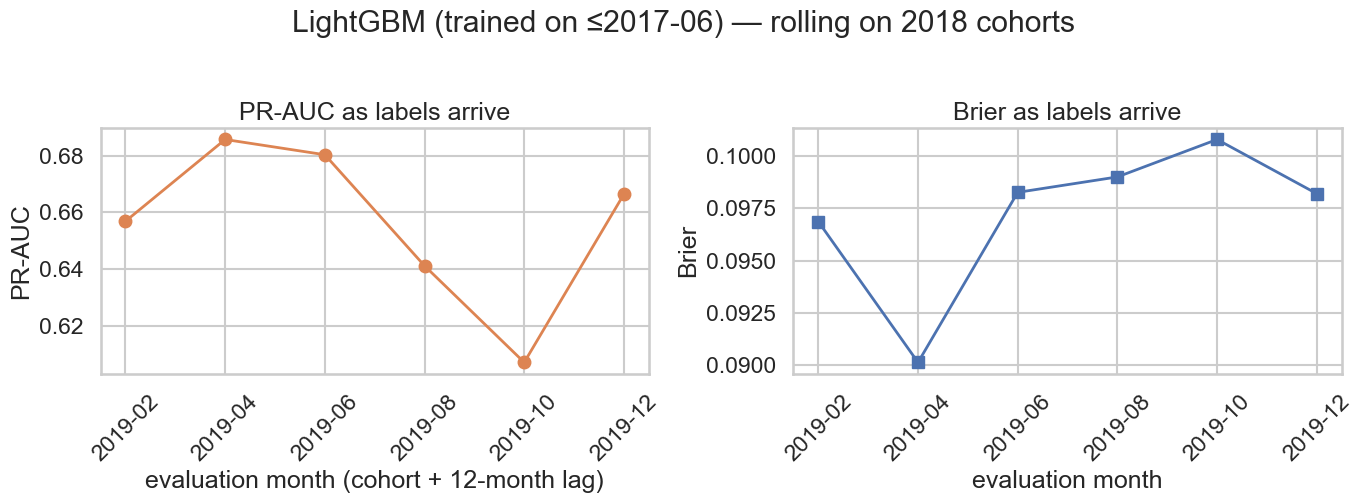

In [6]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
ax = axes[0]
ax.plot(monitor['evaluation_month'], monitor['pr_auc'], marker='o', color='#dd8452', lw=2)
ax.set_xlabel('evaluation month (cohort + 12-month lag)')
ax.set_ylabel('PR-AUC'); ax.set_title('PR-AUC as labels arrive')
ax.tick_params(axis='x', rotation=45)

ax = axes[1]
ax.plot(monitor['evaluation_month'], monitor['brier'], marker='s', color='#4c72b0', lw=2)
ax.set_xlabel('evaluation month'); ax.set_ylabel('Brier')
ax.set_title('Brier as labels arrive')
ax.tick_params(axis='x', rotation=45)

plt.suptitle('LightGBM (trained on \u22642017-06) — rolling on 2018 cohorts', y=1.02)
plt.tight_layout(); plt.savefig(FIG_DIR / 'monitor_label_delay.png', dpi=120, bbox_inches='tight'); plt.show()

**Reading.** Each point is a 2-month cohort window of 2018 origination loans, surfaced with a 12-month label-resolution lag (so the curve x-axis is calendar time roughly mid-2019 onward). PR-AUC drift across windows is the production signal: if it slides downward, retraining is overdue.

Combined with the PSI dashboard above, you have *both* failure modes covered: PSI gives early warning on inputs (within hours of seeing new applications); rolling performance gives confirmation on outputs (months later when labels resolve). Real production teams need both.